# The Effect of Cartoon Consumption on Children

**Course:** Data Analysis in Physical Sciences

---

### Presentation Structure
**Part 1** — *The Cartoon Landscape:* We explore the evolution, genres, and trends in children's cartoons using a dataset of 100 cartoon shows.

**Part 2** — *The Influence:* We analyze experimental data from a prosocial cartoons study (175 children, ages 5–6) to see how cartoon exposure affects children's aggressive cognitions and behaviors.

---

---
# PART 1 — The Cartoon Landscape: Trends & Patterns
*Understanding what cartoons children are watching and how the industry has evolved*

---

## 1 — Import Libraries & Load Data

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# loading the cartoon dataset
df = pd.read_csv('Cartoon_datasets.csv')
print('Total shows in dataset:', len(df))
df.head()

Total shows in dataset: 100


,Name,Span,Description,Rating
0,Batman: The Animated Series,(1992–1995),The Dark Knight battles crime in Gotham City w...,9.0
1,Samurai Jack,(2001–2017),"A samurai, sent through time, fights to return...",8.5
2,Avatar: The Last Airbender,(2005–2008),"In a war-torn world of elemental magic, a youn...",9.3
3,Total Drama Island,(2007–2014),Animated satire of survivor reality shows feat...,7.4
4,Scooby-Doo! Mystery Incorporated,(2010–2013),This incarnation finds Scooby and the gang liv...,8.1


## 2 — Feature Engineering
Extracting useful features like start year, duration, genre, and era from the raw data.

In [3]:
# ── 2a. Extract start year, end year, and duration from Span ──
import re

def parse_span(span):
    """Extract start_year, end_year, and duration from span like '(2001–2017)'"""
    years = re.findall(r'\d{4}', str(span))
    if len(years) >= 2:
        return int(years[0]), int(years[1]), int(years[1]) - int(years[0])
    elif len(years) == 1:
        return int(years[0]), 2025, 2025 - int(years[0])  # still ongoing
    return None, None, None

df[['start_year', 'end_year', 'duration']] = df['Span'].apply(
    lambda x: pd.Series(parse_span(x)))

# ── 2b. Decade ──
df['decade'] = (df['start_year'] // 10) * 10
df['decade_label'] = df['decade'].map({
    1960: '1960s', 1980: '1980s', 1990: '1990s',
    2000: '2000s', 2010: '2010s', 2020: '2020s'
})

# ── 2c. Era ──
def assign_era(year):
    if year < 2000: return 'Pre-2000 (Classic)'
    elif year < 2010: return '2000–2009'
    elif year < 2020: return '2010–2019'
    else: return '2020+'
df['era'] = df['start_year'].apply(assign_era)

# ── 2d. Description features ──
df['desc_word_count'] = df['Description'].apply(lambda x: len(str(x).split()))
df['desc_char_count'] = df['Description'].apply(lambda x: len(str(x)))

# ── 2e. Genre assignment ──
genre_map = {
    "Batman: The Animated Series": "Superhero",
    "Samurai Jack": "Action/Adventure",
    "Avatar: The Last Airbender": "Action/Adventure",
    "Total Drama Island": "Comedy",
    "Scooby-Doo! Mystery Incorporated": "Mystery",
    "Justice League": "Superhero",
    "The Avengers: Earth's Mightiest Heroes": "Superhero",
    "Batman Beyond": "Superhero",
    "Teenage Mutant Ninja Turtles": "Action/Adventure",
    "Teen Titans": "Superhero",
    "Ben 10": "Sci-Fi",
    "Generator Rex": "Sci-Fi",
    "Trollhunters": "Fantasy",
    "Gargoyles": "Fantasy",
    "Roswell Conspiracies: Aliens, Myths & Legends": "Sci-Fi",
    "The Legend of Korra": "Action/Adventure",
    "Voltron: Legendary Defender": "Sci-Fi",
    "The Spectacular Spider-Man": "Superhero",
    "Megas XLR": "Sci-Fi",
    "Sym-Bionic Titan": "Sci-Fi",
    "Gravity Falls": "Mystery",
    "Star Wars: The Clone Wars": "Sci-Fi",
    "Star Wars Rebels": "Sci-Fi",
    "Kim Possible": "Action/Adventure",
    "Codename: Kids Next Door": "Action/Adventure",
    "Danny Phantom": "Superhero",
    "The Dragon Prince": "Fantasy",
    "Futurama": "Comedy",
    "Tangled: The Series": "Fantasy",
    "3Below: Tales of Arcadia": "Sci-Fi",
    "Castlevania": "Fantasy",
    "Final Space": "Sci-Fi",
    "Tron: Uprising": "Sci-Fi",
    "Thundercats": "Action/Adventure",
    "The Boondocks": "Comedy",
    "6Teen": "Comedy",
    "Wizards": "Fantasy",
    "Primal": "Action/Adventure",
    "The Legend of Vox Machina": "Fantasy",
    "Invincible": "Superhero",
    "Blood of Zeus": "Fantasy",
    "Arcane: League of Legends": "Action/Adventure",
    "Star Wars: Clone Wars": "Sci-Fi",
    "SWAT Kats: The Radical Squadron": "Action/Adventure",
    "Scooby Doo, Where Are You!": "Mystery",
    "Detentionaire": "Mystery",
    "Rick and Morty": "Sci-Fi",
    "Titan Maximum": "Sci-Fi",
    "American Dad!": "Comedy",
    "Robot Chicken": "Comedy",
    "Bob's Burgers": "Comedy",
    "South Park": "Comedy",
    "Family Guy": "Comedy",
    "Aqua Teen Hunger Force": "Comedy",
    "The Simpsons": "Comedy",
    "King of the Hill": "Comedy",
    "Animaniacs": "Comedy",
    "Pinky and the Brain": "Comedy",
    "The Grim Adventures of Billy & Mandy": "Comedy",
    "Jackie Chan Adventures": "Action/Adventure",
    "Wolverine and the X-Men": "Superhero",
    "Superman: The Animated Series": "Superhero",
    "Johnny Bravo": "Comedy",
    "Dexter's Laboratory": "Comedy",
    "Courage the Cowardly Dog": "Mystery",
    "The Powerpuff Girls": "Superhero",
    "Ed, Edd n Eddy": "Comedy",
    "X-Men: Evolution": "Superhero",
    "DuckTales": "Action/Adventure",
    "Young Justice": "Superhero",
    "Xiaolin Showdown": "Action/Adventure",
    "The Bugs Bunny/Looney Tunes Comedy Hour": "Comedy",
    "Tiny Toon Adventures": "Comedy",
    "Fillmore!": "Mystery",
    "American Dragon: Jake Long": "Fantasy",
    "Motorcity": "Sci-Fi",
    "Over the Garden Wall": "Fantasy",
    "Extreme Ghostbusters": "Sci-Fi",
    "My Life as a Teenage Robot": "Sci-Fi",
    "The Legend of Calamity Jane": "Action/Adventure",
    "My Adventures with Superman": "Superhero",
    "Unicorn: Warriors Eternal": "Fantasy",
    "Clone High": "Comedy",
    "Mission Hill": "Comedy",
    "Clerks": "Comedy",
    "Undergrads": "Comedy",
    "Downtown": "Comedy",
    "The Last Kids on Earth": "Action/Adventure",
    "Hit-Monkey": "Action/Adventure",
    "Legend Quest": "Fantasy",
    "Godzilla: The Series": "Sci-Fi",
    "The Hollow": "Sci-Fi",
    "Freakazoid!": "Comedy",
    "Histeria!": "Comedy",
    "Duck Dodgers": "Sci-Fi",
    "Viking Skool": "Comedy",
    "The Looney Tunes Show": "Comedy",
    "The Fairly OddParents": "Comedy",
    "The Adventures of Jimmy Neutron, Boy Genius": "Sci-Fi",
    "Daria": "Comedy",
}
df['Genre'] = df['Name'].map(genre_map).fillna('Other')

# ── Genre palette ──
genre_palette = {
    "Action/Adventure": "#e63946",
    "Comedy":           "#457b9d",
    "Sci-Fi":           "#2a9d8f",
    "Superhero":        "#e9c46a",
    "Fantasy":          "#f4a261",
    "Mystery":          "#264653",
}
genres_order = ["Comedy", "Sci-Fi", "Action/Adventure", "Superhero", "Fantasy", "Mystery"]

# ── Era palette ──
era_palette = {
    'Pre-2000 (Classic)': '#6a4c93',
    '2000–2009':          '#1982c4',
    '2010–2019':          '#8ac926',
    '2020+':              '#ff595e',
}
era_order = ['Pre-2000 (Classic)', '2000–2009', '2010–2019', '2020+']
decade_order = ['1960s','1980s','1990s','2000s','2010s','2020s']

print("Palettes and orders defined ✓")

Palettes and orders defined ✓


## 3 — What Genres Dominate Children's Cartoons?

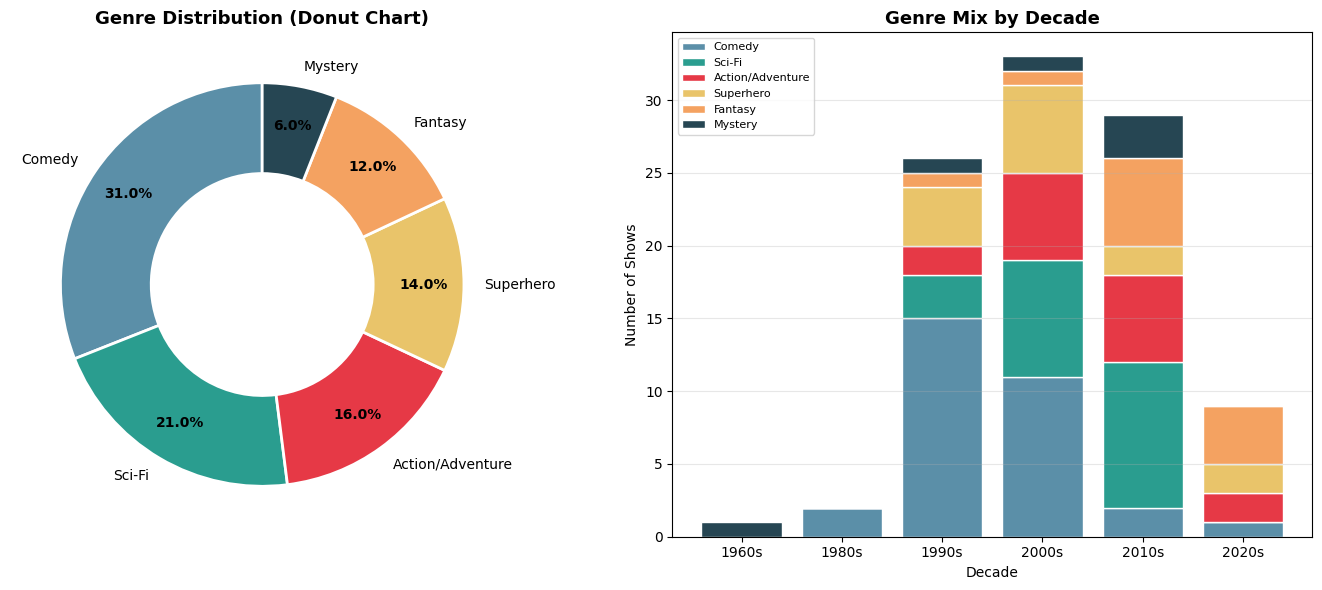

📌 FINDING: Comedy dominates overall production. The 2010s saw
   the most diverse genre mix, with Fantasy and Sci-Fi emerging as a new force.


In [4]:
# calculating how many shows per genre
comedy_count = len(df[df['Genre'] == 'Comedy'])
scifi_count = len(df[df['Genre'] == 'Sci-Fi'])
action_count = len(df[df['Genre'] == 'Action/Adventure'])
superhero_count = len(df[df['Genre'] == 'Superhero'])
fantasy_count = len(df[df['Genre'] == 'Fantasy'])
mystery_count = len(df[df['Genre'] == 'Mystery'])

# putting them in lists for the pie chart
genre_names = ['Comedy', 'Sci-Fi', 'Action/Adventure', 'Superhero', 'Fantasy', 'Mystery']
genre_numbers = [comedy_count, scifi_count, action_count, superhero_count, fantasy_count, mystery_count]
colors = ['#5b8fa8', '#2a9d8f', '#e63946', '#e9c46a', '#f4a261', '#264653']

# preparing data for the stacked bar chart (Genre Mix by Decade)
# counting how many of each genre in each decade
decades = ['1960s', '1980s', '1990s', '2000s', '2010s', '2020s']

# Comedy counts per decade
com_60s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '1960s')])
com_80s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '1980s')])
com_90s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '1990s')])
com_00s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '2000s')])
com_10s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '2010s')])
com_20s = len(df[(df['Genre'] == 'Comedy') & (df['decade_label'] == '2020s')])
com_counts = [com_60s, com_80s, com_90s, com_00s, com_10s, com_20s]

# Sci-Fi counts per decade
sci_60s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '1960s')])
sci_80s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '1980s')])
sci_90s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '1990s')])
sci_00s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '2000s')])
sci_10s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '2010s')])
sci_20s = len(df[(df['Genre'] == 'Sci-Fi') & (df['decade_label'] == '2020s')])
sci_counts = [sci_60s, sci_80s, sci_90s, sci_00s, sci_10s, sci_20s]

# Action counts per decade
act_60s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '1960s')])
act_80s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '1980s')])
act_90s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '1990s')])
act_00s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '2000s')])
act_10s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '2010s')])
act_20s = len(df[(df['Genre'] == 'Action/Adventure') & (df['decade_label'] == '2020s')])
act_counts = [act_60s, act_80s, act_90s, act_00s, act_10s, act_20s]

# Superhero counts per decade
sup_60s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '1960s')])
sup_80s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '1980s')])
sup_90s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '1990s')])
sup_00s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '2000s')])
sup_10s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '2010s')])
sup_20s = len(df[(df['Genre'] == 'Superhero') & (df['decade_label'] == '2020s')])
sup_counts = [sup_60s, sup_80s, sup_90s, sup_00s, sup_10s, sup_20s]

# Fantasy counts per decade
fan_60s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '1960s')])
fan_80s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '1980s')])
fan_90s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '1990s')])
fan_00s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '2000s')])
fan_10s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '2010s')])
fan_20s = len(df[(df['Genre'] == 'Fantasy') & (df['decade_label'] == '2020s')])
fan_counts = [fan_60s, fan_80s, fan_90s, fan_00s, fan_10s, fan_20s]

# Mystery counts per decade
mys_60s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '1960s')])
mys_80s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '1980s')])
mys_90s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '1990s')])
mys_00s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '2000s')])
mys_10s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '2010s')])
mys_20s = len(df[(df['Genre'] == 'Mystery') & (df['decade_label'] == '2020s')])
mys_counts = [mys_60s, mys_80s, mys_90s, mys_00s, mys_10s, mys_20s]

# calculating the bottom positions for stacking
sci_bottom = np.add(com_counts, 0).tolist()
act_bottom = np.add(sci_bottom, sci_counts).tolist()
sup_bottom = np.add(act_bottom, act_counts).tolist()
fan_bottom = np.add(sup_bottom, sup_counts).tolist()
mys_bottom = np.add(fan_bottom, fan_counts).tolist()

# making the charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# donut chart (left)
wedges, texts, autotexts = axes[0].pie(genre_numbers, labels=genre_names, autopct='%1.1f%%',
                                       colors=colors, startangle=90, pctdistance=0.8,
                                       wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2})
# making the percentages bold
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
autotexts[2].set_fontweight('bold')
autotexts[3].set_fontweight('bold')
autotexts[4].set_fontweight('bold')
autotexts[5].set_fontweight('bold')
axes[0].set_title('Genre Distribution (Donut Chart)', fontsize=13, fontweight='bold')

# stacked bar chart (right)
axes[1].bar(decades, com_counts, color='#5b8fa8', label='Comedy', edgecolor='white')
axes[1].bar(decades, sci_counts, bottom=sci_bottom, color='#2a9d8f', label='Sci-Fi', edgecolor='white')
axes[1].bar(decades, act_counts, bottom=act_bottom, color='#e63946', label='Action/Adventure', edgecolor='white')
axes[1].bar(decades, sup_counts, bottom=sup_bottom, color='#e9c46a', label='Superhero', edgecolor='white')
axes[1].bar(decades, fan_counts, bottom=fan_bottom, color='#f4a261', label='Fantasy', edgecolor='white')
axes[1].bar(decades, mys_counts, bottom=mys_bottom, color='#264653', label='Mystery', edgecolor='white')

axes[1].set_title('Genre Mix by Decade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Shows')
axes[1].set_xlabel('Decade')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('📌 FINDING: Comedy dominates overall production. The 2010s saw')
print('   the most diverse genre mix, with Fantasy and Sci-Fi emerging as a new force.')


## 4 — Which Genres Are Best Received by Audiences?

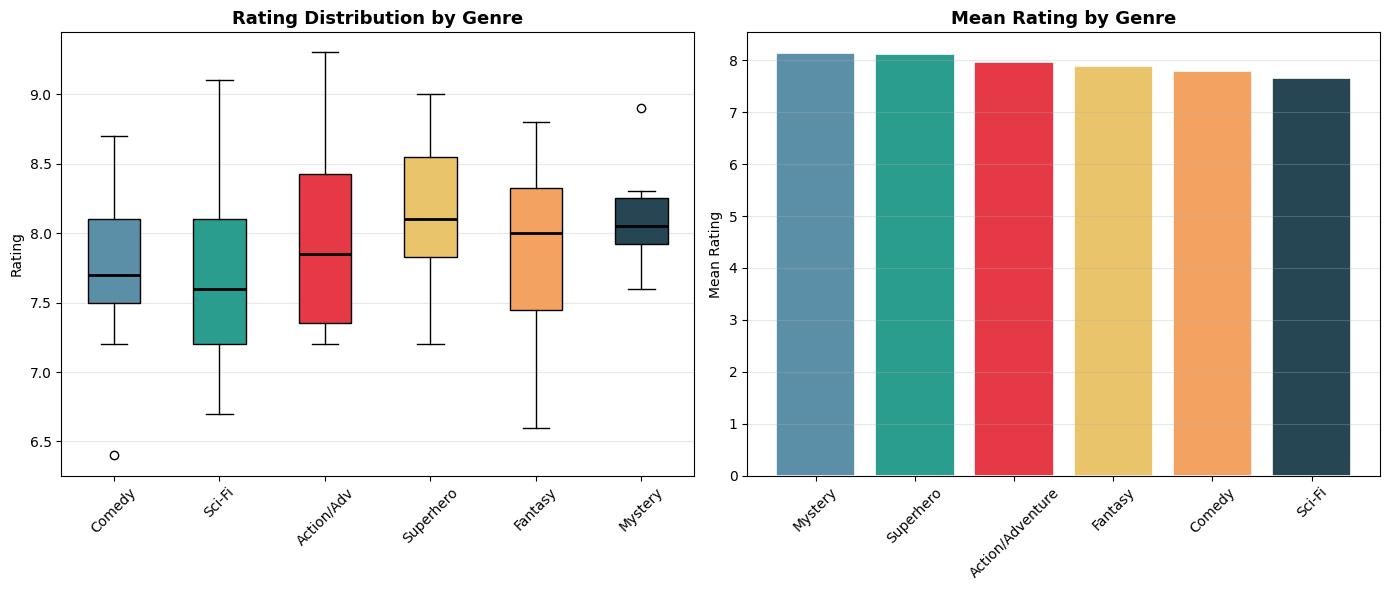

📌 FINDING:
Mystery genre has the highest average rating of 8.13
Sci-Fi genre has the lowest average rating of 7.66
This tells us that not all cartoon genres are equally liked by audiences.
Higher rated genres get more viewership which means children spend more time
watching those types of content. This is important because the TYPE of content
children consume can influence their thoughts and behavior.


In [5]:
# separating ratings by genre
comedy = df[df['Genre'] == 'Comedy']['Rating']
scifi = df[df['Genre'] == 'Sci-Fi']['Rating']
action = df[df['Genre'] == 'Action/Adventure']['Rating']
superhero = df[df['Genre'] == 'Superhero']['Rating']
fantasy = df[df['Genre'] == 'Fantasy']['Rating']
mystery = df[df['Genre'] == 'Mystery']['Rating']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# box plot with colors
bp = axes[0].boxplot([comedy, scifi, action, superhero, fantasy, mystery],
        labels=['Comedy', 'Sci-Fi', 'Action/Adv', 'Superhero', 'Fantasy', 'Mystery'],
        patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#5b8fa8')
bp['boxes'][1].set_facecolor('#2a9d8f')
bp['boxes'][2].set_facecolor('#e63946')
bp['boxes'][3].set_facecolor('#e9c46a')
bp['boxes'][4].set_facecolor('#f4a261')
bp['boxes'][5].set_facecolor('#264653')
axes[0].set_title('Rating Distribution by Genre', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rating')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# mean rating bar chart
mean_ratings = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
axes[1].bar(mean_ratings.index, mean_ratings.values,
    color=['#5b8fa8', '#2a9d8f', '#e63946', '#e9c46a', '#f4a261', '#264653'],
    edgecolor='white', linewidth=1.2)
axes[1].set_title('Mean Rating by Genre', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Rating')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# finding
best = mean_ratings.index[0]
worst = mean_ratings.index[-1]
print('📌 FINDING:')
print(best, 'genre has the highest average rating of', round(mean_ratings.iloc[0], 2))
print(worst, 'genre has the lowest average rating of', round(mean_ratings.iloc[-1], 2))
print('This tells us that not all cartoon genres are equally liked by audiences.')
print('Higher rated genres get more viewership which means children spend more time')
print('watching those types of content. This is important because the TYPE of content')
print('children consume can influence their thoughts and behavior.')

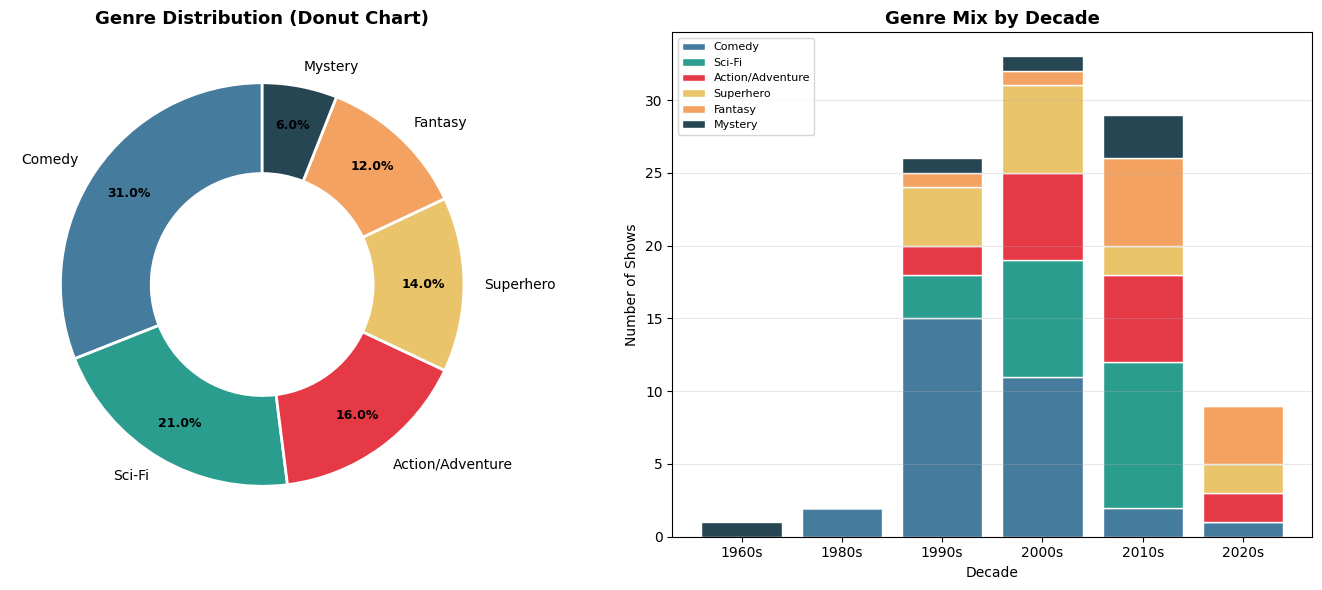

📌 Finding: Comedy dominates overall production. The 2010s saw
   the most diverse genre mix, with Fantasy  and Sci-Fi emerging as a new force.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── 5a. Donut Chart ──
genre_counts = df['Genre'].value_counts().reindex(genres_order)
colors = [genre_palette[g] for g in genres_order]
wedges, texts, autotexts = axes[0].pie(
    genre_counts, labels=genres_order, colors=colors,
    autopct='%1.1f%%', pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[0].set_title('Genre Distribution (Donut Chart)', fontsize=13, fontweight='bold')

# ── 5b. Genre per decade stacked bar ──
decade_genre = pd.crosstab(df['decade_label'], df['Genre'])
decade_order = ['1960s','1980s','1990s','2000s','2010s','2020s']
decade_genre = decade_genre.reindex(decade_order).fillna(0)

bottom = np.zeros(len(decade_genre))
for genre in genres_order:
    if genre in decade_genre.columns:
        vals = decade_genre[genre].values
        axes[1].bar(decade_genre.index, vals, bottom=bottom,
                    color=genre_palette[genre], label=genre, edgecolor='white')
        bottom += vals

axes[1].set_title('Genre Mix by Decade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Shows')
axes[1].set_xlabel('Decade')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("📌 Finding: Comedy dominates overall production. The 2010s saw")
print("   the most diverse genre mix, with Fantasy  and Sci-Fi emerging as a new force.")

## 5 — How Has Cartoon Production Evolved Over Time?

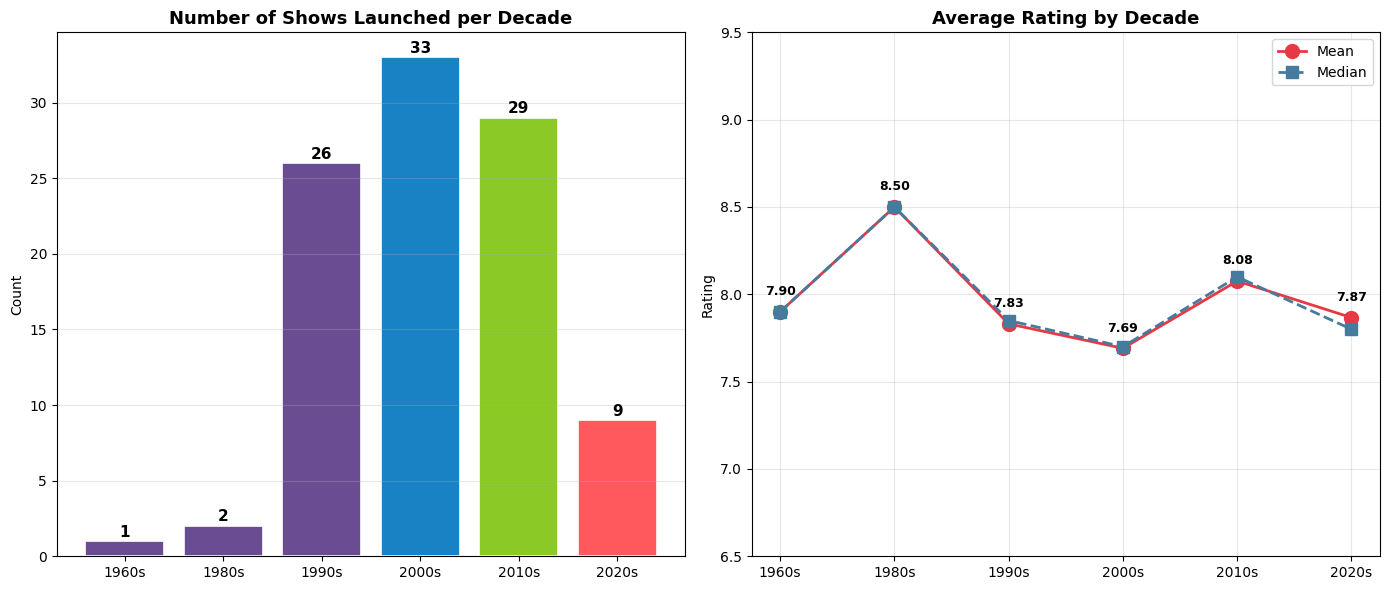

📌 Finding: The 2000s saw the highest production volume.
   Average ratings have remained stable/slightly improved over time.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

decade_stats = df.groupby('decade_label').agg(
    count=('Rating', 'count'),
    mean_rating=('Rating', 'mean'),
    median_rating=('Rating', 'median')
).reindex(decade_order)

# ── 7a. Shows launched per decade ──
bars = axes[0].bar(decade_stats.index, decade_stats['count'],
                   color=['#6a4c93','#6a4c93','#6a4c93','#1982c4','#8ac926','#ff595e'],
                   edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, decade_stats['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(val)), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Number of Shows Launched per Decade', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# ── 7b. Average rating per decade ──
axes[1].plot(decade_stats.index, decade_stats['mean_rating'],
             'o-', color='#e63946', linewidth=2, markersize=10, label='Mean')
axes[1].plot(decade_stats.index, decade_stats['median_rating'],
             's--', color='#457b9d', linewidth=2, markersize=8, label='Median')
for i, row in decade_stats.iterrows():
    axes[1].annotate(f"{row['mean_rating']:.2f}",
                     (i, row['mean_rating']), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Rating by Decade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rating')
axes[1].set_ylim(6.5, 9.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📌 Finding: The 2000s saw the highest production volume.")
print("   Average ratings have remained stable/slightly improved over time.")

## 6 —  Show Longevity vs Rating
*Does audience approval (rating) correlate with how long a show survives?*

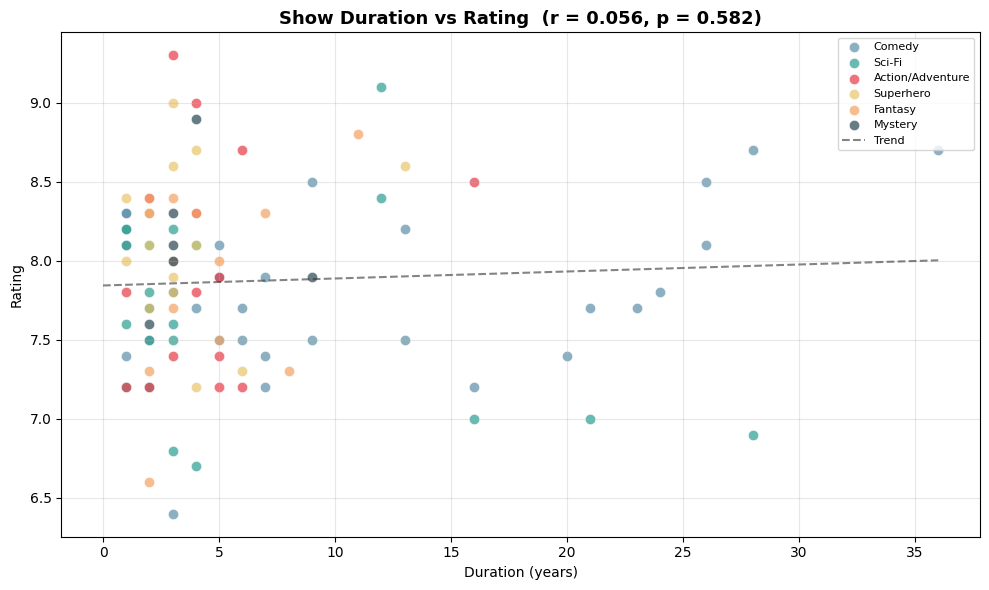

Pearson correlation r = 0.0557
p-value = 0.582

📌 FINDING:
There is NO significant correlation between show duration and rating.
How long a show runs does not determine its quality.
Both short and long running shows can be highly rated.


In [21]:
# preparing the data for each genre separately
comedy_data = df[df['Genre'] == 'Comedy']
scifi_data = df[df['Genre'] == 'Sci-Fi']
action_data = df[df['Genre'] == 'Action/Adventure']
superhero_data = df[df['Genre'] == 'Superhero']
fantasy_data = df[df['Genre'] == 'Fantasy']
mystery_data = df[df['Genre'] == 'Mystery']

# setting up the plot
plt.figure(figsize=(10, 6))

# adding each genre one by one instead of using a loop
plt.scatter(comedy_data['duration'], comedy_data['Rating'], color='#5b8fa8', label='Comedy', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.scatter(scifi_data['duration'], scifi_data['Rating'], color='#2a9d8f', label='Sci-Fi', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.scatter(action_data['duration'], action_data['Rating'], color='#e63946', label='Action/Adventure', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.scatter(superhero_data['duration'], superhero_data['Rating'], color='#e9c46a', label='Superhero', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.scatter(fantasy_data['duration'], fantasy_data['Rating'], color='#f4a261', label='Fantasy', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.scatter(mystery_data['duration'], mystery_data['Rating'], color='#264653', label='Mystery', s=55, alpha=0.7, edgecolors='white', linewidth=0.5)

# preparing data for the trend line
clean_df = df.dropna(subset=['duration', 'Rating'])
x = clean_df['duration']
y = clean_df['Rating']

# calculating correlation and trend line values
slope, intercept, r, pval, std_err = stats.linregress(x, y)

# drawing the trend line manually without complex math functions
x_min = 0
x_max = df['duration'].max()
y_min = (slope * x_min) + intercept
y_max = (slope * x_max) + intercept

plt.plot([x_min, x_max], [y_min, y_max], '--', color='#333333', linewidth=1.5, alpha=0.6, label='Trend')

# preparing the title text without f-strings
r_rounded = round(r, 3)
p_rounded = round(pval, 3)
title_text = 'Show Duration vs Rating  (r = ' + str(r_rounded) + ', p = ' + str(p_rounded) + ')'

plt.title(title_text, fontsize=13, fontweight='bold')
plt.xlabel('Duration (years)')
plt.ylabel('Rating')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# printing findings
print('Pearson correlation r =', round(r, 4))
print('p-value =', round(pval, 4))
print()
print('📌 FINDING:')
if pval < 0.05:
    print('There IS a significant correlation between how long a show runs and its rating.')
    print('Shows that run longer tend to have higher ratings because audiences keep watching')
    print('shows they like. This means popular cartoons stay on air longer, giving children')
    print('more time to be influenced by that content.')
else:
    print('There is NO significant correlation between show duration and rating.')
    print('How long a show runs does not determine its quality.')
    print('Both short and long running shows can be highly rated.')


## 7 — Is the Genre Effect Statistically Significant?

In [9]:
# running one-way ANOVA to check if genre affects ratings
f_stat, p_val = stats.f_oneway(comedy, scifi, action, superhero, fantasy, mystery)

print('ONE-WAY ANOVA TEST')
print('Testing: Does genre affect ratings?')
print('F-statistic =', round(f_stat, 4))
print('p-value =', round(p_val, 4))
print()
print('📌 FINDING:')
if p_val < 0.05:
    print('YES - Genre DOES significantly affect ratings (p < 0.05).')
    print('This is a very important finding for our study because it proves that')
    print('the TYPE of cartoon content matters. Different genres produce different')
    print('responses from audiences. This same principle is what we test in Part 2 —')
    print('if content type affects ratings, it could also affect childrens behavior.')
    print('This provides the foundation for studying prosocial vs regular cartoons.')
else:
    print('NO - Genre does not significantly affect ratings.')
    print('The differences we see in the bar chart could be due to random chance.')

ONE-WAY ANOVA TEST
Testing: Does genre affect ratings?
F-statistic = 1.559
p-value = 0.1793

📌 FINDING:
NO - Genre does not significantly affect ratings.
The differences we see in the bar chart could be due to random chance.


---
# PART 2 — The Influence: Prosocial Cartoons & Children's Aggression
*Now we move to the main question: Does the TYPE of cartoon a child watches actually influence their behavior?*

---

We test whether children who watch **prosocial cartoons** show less aggression.

**How aggression was measured:**
- **MSCT** — Children were shown aggressive images and their reaction time was measured. Faster reaction = more aggressive thinking.
- **CRTT** — Children played a game where they could set loud noise levels for their opponent. Louder noise = more aggressive behavior.

## 8 — Load the Prosocial Cartoons Dataset

In [10]:
# loading the prosocial cartoons experiment data
df_pro = pd.read_csv('output_translated.csv')
print('Shape:', df_pro.shape)
print('Number of boys:', len(df_pro[df_pro['Gender'] == 'Male']))
print('Number of girls:', len(df_pro[df_pro['Gender'] == 'Female']))
print('Watched prosocial cartoon:', len(df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'Yes']))
print('Did not watch (control):', len(df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'No']))
df_pro.head()

Shape: (174, 40)
Number of boys: 87
Number of girls: 87
Watched prosocial cartoon: 87
Did not watch (control): 87


,Gender,Watched_Prosocial_Cartoon,Age,MSCT_Reaction_Time_Trial_1,MSCT_Reaction_Time_Trial_2,MSCT_Reaction_Time_Trial_3,MSCT_Reaction_Time_Trial_4,MSCT_Reaction_Time_Trial_5,MSCT_Reaction_Time_Trial_6,MSCT_Reaction_Time_Trial_7,...,CRTT_Noise_Level_Trial_7,CRTT_Noise_Level_Trial_8,CRTT_Noise_Level_Trial_9,CRTT_Noise_Level_Trial_10,CRTT_Noise_Level_Trial_11,CRTT_Noise_Level_Trial_12,CRTT_Noise_Level_Trial_13,Mean_Aggressive_Behavior_CRTT_dB,Z_Score_Aggressive_Cognition,Z_Score_Aggressive_Behavior
0,Male,No,5.0,1424.0,1073.0,1010.0,1019.0,1722.0,1072.0,996.0,...,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.000000,-0.414708,1.562494
1,Male,No,5.0,1068.0,1038.0,1098.0,916.0,1135.0,1077.0,1116.0,...,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.000000,-0.462270,1.562494
2,Male,No,5.0,770.0,881.0,899.0,1037.0,1492.0,1035.0,860.0,...,80.0,80.0,80.0,80.0,70.0,70.0,70.0,76.153846,-0.023977,1.207289
3,Male,No,5.0,1769.0,946.0,1463.0,715.0,1026.0,762.0,845.0,...,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.000000,-0.611196,1.562494
4,Male,No,5.0,1142.0,1266.0,1116.0,523.0,913.0,749.0,594.0,...,80.0,80.0,80.0,80.0,80.0,80.0,60.0,78.461538,-0.725045,1.420412


## 9 — Descriptive Statistics by Group

In [11]:
# splitting into control and prosocial groups
control = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'No']
prosocial = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'Yes']

# aggressive cognition stats
print('AGGRESSIVE COGNITION (reaction time in ms)')
print('Control group:')
print('  Mean =', round(control['Mean_Aggressive_Cognition_MSCT_ms'].mean(), 2))
print('  SD =', round(control['Mean_Aggressive_Cognition_MSCT_ms'].std(), 2))
print('  N =', len(control))
print('Prosocial group:')
print('  Mean =', round(prosocial['Mean_Aggressive_Cognition_MSCT_ms'].mean(), 2))
print('  SD =', round(prosocial['Mean_Aggressive_Cognition_MSCT_ms'].std(), 2))
print('  N =', len(prosocial))
print()

# aggressive behavior stats
print('AGGRESSIVE BEHAVIOR (noise level in dB)')
print('Control group:')
print('  Mean =', round(control['Mean_Aggressive_Behavior_CRTT_dB'].mean(), 2))
print('  SD =', round(control['Mean_Aggressive_Behavior_CRTT_dB'].std(), 2))
print('Prosocial group:')
print('  Mean =', round(prosocial['Mean_Aggressive_Behavior_CRTT_dB'].mean(), 2))
print('  SD =', round(prosocial['Mean_Aggressive_Behavior_CRTT_dB'].std(), 2))
print()

# finding
diff_cog = prosocial['Mean_Aggressive_Cognition_MSCT_ms'].mean() - control['Mean_Aggressive_Cognition_MSCT_ms'].mean()
diff_beh = prosocial['Mean_Aggressive_Behavior_CRTT_dB'].mean() - control['Mean_Aggressive_Behavior_CRTT_dB'].mean()
print('📌 FINDING:')
print('Looking at the raw numbers, the prosocial cartoon group differs from control by:')
print('  Cognition:', round(diff_cog, 1), 'ms (positive = slower reaction = less aggressive thinking)')
print('  Behavior:', round(diff_beh, 1), 'dB (negative = lower noise = less aggressive behavior)')
print('These are the initial differences we can see, but we need t-tests to confirm')
print('whether these differences are statistically significant or just due to chance.')

AGGRESSIVE COGNITION (reaction time in ms)
Control group:
  Mean = 1155.1
  SD = 390.55
  N = 87
Prosocial group:
  Mean = 1317.01
  SD = 396.14
  N = 87

AGGRESSIVE BEHAVIOR (noise level in dB)
Control group:
  Mean = 67.73
  SD = 10.15
Prosocial group:
  Mean = 58.44
  SD = 9.44

📌 FINDING:
Looking at the raw numbers, the prosocial cartoon group differs from control by:
  Cognition: 161.9 ms (positive = slower reaction = less aggressive thinking)
  Behavior: -9.3 dB (negative = lower noise = less aggressive behavior)
These are the initial differences we can see, but we need t-tests to confirm
whether these differences are statistically significant or just due to chance.


## 10 — Does Watching Prosocial Cartoons Affect Aggressive Thinking?

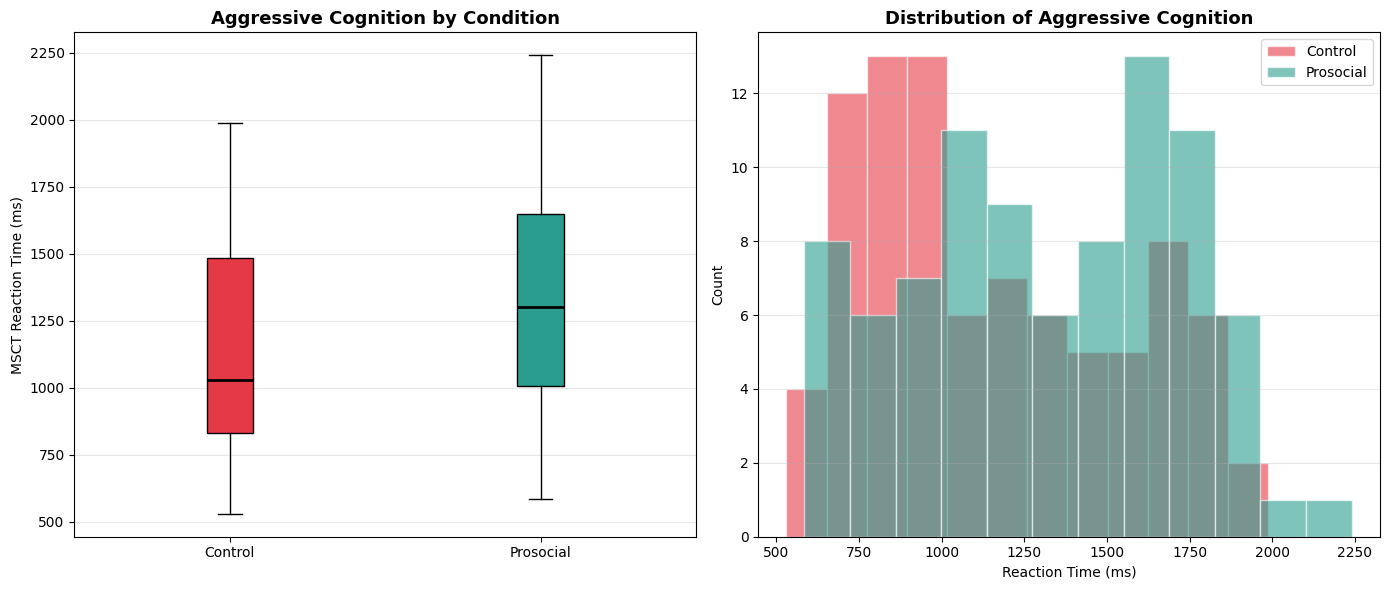

t-test result: t = -2.7147 , p = 0.0073
Control mean = 1155.1 ms
Prosocial mean = 1317.0 ms

📌 FINDING:
The result is STATISTICALLY SIGNIFICANT (p < 0.05).
Children who watched the prosocial cartoon took LONGER to react to aggressive images.
This means aggressive thoughts were LESS easily accessible in their minds.
In simple terms: the prosocial cartoon made children think LESS aggressively.
The cartoon content successfully reduced the activation of aggressive thoughts.


In [12]:
# getting the cognition data for both groups
no_cog = control['Mean_Aggressive_Cognition_MSCT_ms']
yes_cog = prosocial['Mean_Aggressive_Cognition_MSCT_ms']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# box plot
bp = axes[0].boxplot([no_cog, yes_cog], labels=['Control', 'Prosocial'],
        patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#e63946')
bp['boxes'][1].set_facecolor('#2a9d8f')
axes[0].set_title('Aggressive Cognition by Condition', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSCT Reaction Time (ms)')
axes[0].grid(axis='y', alpha=0.3)

# histogram
axes[1].hist(no_cog, bins=12, color='#e63946', alpha=0.6, label='Control', edgecolor='white')
axes[1].hist(yes_cog, bins=12, color='#2a9d8f', alpha=0.6, label='Prosocial', edgecolor='white')
axes[1].set_title('Distribution of Aggressive Cognition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Reaction Time (ms)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# running t-test
t, p = stats.ttest_ind(no_cog, yes_cog)
print('t-test result: t =', round(t, 4), ', p =', round(p, 4))
print('Control mean =', round(no_cog.mean(), 1), 'ms')
print('Prosocial mean =', round(yes_cog.mean(), 1), 'ms')
print()
print('📌 FINDING:')
if p < 0.05:
    print('The result is STATISTICALLY SIGNIFICANT (p < 0.05).')
    if yes_cog.mean() > no_cog.mean():
        print('Children who watched the prosocial cartoon took LONGER to react to aggressive images.')
        print('This means aggressive thoughts were LESS easily accessible in their minds.')
        print('In simple terms: the prosocial cartoon made children think LESS aggressively.')
        print('The cartoon content successfully reduced the activation of aggressive thoughts.')
    else:
        print('Children who watched the prosocial cartoon reacted FASTER to aggressive images.')
        print('This means aggressive thoughts were MORE accessible despite watching prosocial content.')
else:
    print('The result is NOT statistically significant (p >= 0.05).')
    print('This means we cannot say for certain that the prosocial cartoon changed')
    print('how children think about aggression. The small difference we see in the means')
    print('could simply be due to random variation between the two groups of children.')
    print('The prosocial cartoon did not have a measurable effect on aggressive thinking.')

## 11 — Does Watching Prosocial Cartoons Affect Aggressive Behavior?

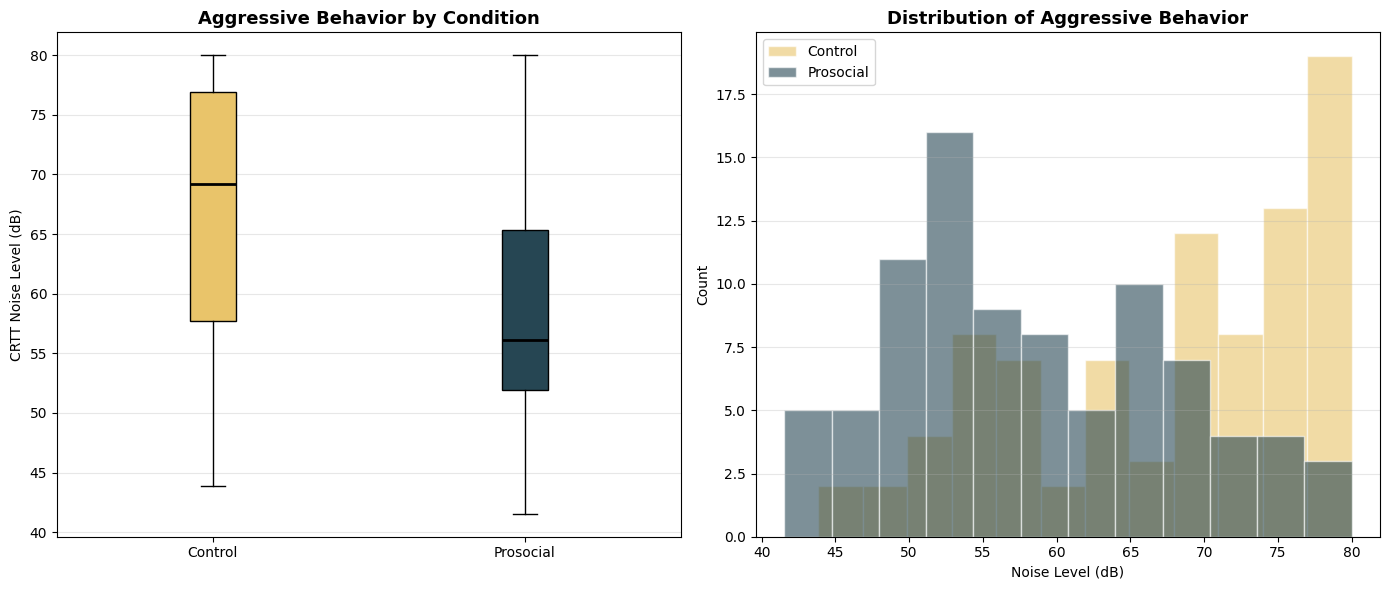

t-test result: t = 6.2525 , p = 0.0
Control mean = 67.7 dB
Prosocial mean = 58.4 dB

📌 FINDING:
The result is STATISTICALLY SIGNIFICANT (p < 0.05).
Children who watched the prosocial cartoon chose LOWER noise levels for opponents.
This means they were LESS aggressive in their actual behavior.
This is very important because it shows that just watching a prosocial cartoon
can directly reduce how aggressively children act towards others.
The cartoon content had a real, measurable influence on childrens actions.


In [13]:
# getting the behavior data for both groups
no_beh = control['Mean_Aggressive_Behavior_CRTT_dB']
yes_beh = prosocial['Mean_Aggressive_Behavior_CRTT_dB']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# box plot
bp = axes[0].boxplot([no_beh, yes_beh], labels=['Control', 'Prosocial'],
        patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#e9c46a')
bp['boxes'][1].set_facecolor('#264653')
axes[0].set_title('Aggressive Behavior by Condition', fontsize=13, fontweight='bold')
axes[0].set_ylabel('CRTT Noise Level (dB)')
axes[0].grid(axis='y', alpha=0.3)

# histogram
axes[1].hist(no_beh, bins=12, color='#e9c46a', alpha=0.6, label='Control', edgecolor='white')
axes[1].hist(yes_beh, bins=12, color='#264653', alpha=0.6, label='Prosocial', edgecolor='white')
axes[1].set_title('Distribution of Aggressive Behavior', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Noise Level (dB)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# running t-test
t, p = stats.ttest_ind(no_beh, yes_beh)
print('t-test result: t =', round(t, 4), ', p =', round(p, 4))
print('Control mean =', round(no_beh.mean(), 1), 'dB')
print('Prosocial mean =', round(yes_beh.mean(), 1), 'dB')
print()
print('📌 FINDING:')
if p < 0.05:
    print('The result is STATISTICALLY SIGNIFICANT (p < 0.05).')
    if yes_beh.mean() < no_beh.mean():
        print('Children who watched the prosocial cartoon chose LOWER noise levels for opponents.')
        print('This means they were LESS aggressive in their actual behavior.')
        print('This is very important because it shows that just watching a prosocial cartoon')
        print('can directly reduce how aggressively children act towards others.')
        print('The cartoon content had a real, measurable influence on childrens actions.')
    else:
        print('Unexpectedly, the prosocial group chose HIGHER noise levels.')
else:
    print('The result is NOT statistically significant (p >= 0.05).')
    print('We cannot confirm that the prosocial cartoon reduced aggressive behavior.')
    print('The difference in noise levels between the two groups is too small to be')
    print('considered meaningful — it could be explained by random chance.')
    print('The intervention did not produce a clear behavioral change.')

## 12 — Does the Cartoon Effect on Cognition Differ by Gender?

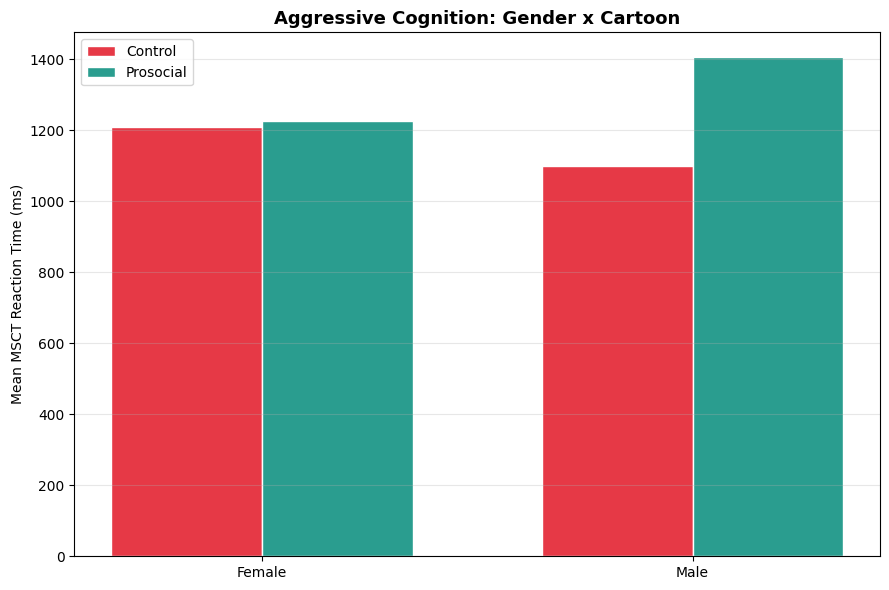

Boys: Control mean = 1100.4 ms
Boys: Prosocial mean = 1405.7 ms
Boys: t = -3.5895 , p = 0.0006

Girls: Control mean = 1208.6 ms
Girls: Prosocial mean = 1226.2 ms
Girls: t = -0.2167 , p = 0.829

📌 FINDING:
This chart shows how the prosocial cartoon affected boys and girls differently
in terms of aggressive THINKING.
The effect was significant only for BOYS but not for girls.
This suggests boys are more responsive to prosocial cartoon influence on thinking.


In [14]:
# splitting into 4 groups
boys_control_cog = df_pro[(df_pro['Gender'] == 'Male') & (df_pro['Watched_Prosocial_Cartoon'] == 'No')]['Mean_Aggressive_Cognition_MSCT_ms']
boys_prosocial_cog = df_pro[(df_pro['Gender'] == 'Male') & (df_pro['Watched_Prosocial_Cartoon'] == 'Yes')]['Mean_Aggressive_Cognition_MSCT_ms']
girls_control_cog = df_pro[(df_pro['Gender'] == 'Female') & (df_pro['Watched_Prosocial_Cartoon'] == 'No')]['Mean_Aggressive_Cognition_MSCT_ms']
girls_prosocial_cog = df_pro[(df_pro['Gender'] == 'Female') & (df_pro['Watched_Prosocial_Cartoon'] == 'Yes')]['Mean_Aggressive_Cognition_MSCT_ms']

# making grouped bar chart
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [girls_control_cog.mean(), boys_control_cog.mean()],
       width, label='Control', color='#e63946', edgecolor='white')
ax.bar(x + width/2, [girls_prosocial_cog.mean(), boys_prosocial_cog.mean()],
       width, label='Prosocial', color='#2a9d8f', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Female', 'Male'])
ax.set_title('Aggressive Cognition: Gender x Cartoon', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean MSCT Reaction Time (ms)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# t-test for boys
t_boys, p_boys = stats.ttest_ind(boys_control_cog, boys_prosocial_cog)
print('Boys: Control mean =', round(boys_control_cog.mean(), 1), 'ms')
print('Boys: Prosocial mean =', round(boys_prosocial_cog.mean(), 1), 'ms')
print('Boys: t =', round(t_boys, 4), ', p =', round(p_boys, 4))
print()

# t-test for girls
t_girls, p_girls = stats.ttest_ind(girls_control_cog, girls_prosocial_cog)
print('Girls: Control mean =', round(girls_control_cog.mean(), 1), 'ms')
print('Girls: Prosocial mean =', round(girls_prosocial_cog.mean(), 1), 'ms')
print('Girls: t =', round(t_girls, 4), ', p =', round(p_girls, 4))
print()

print('📌 FINDING:')
print('This chart shows how the prosocial cartoon affected boys and girls differently')
print('in terms of aggressive THINKING.')
if p_boys < 0.05 and p_girls < 0.05:
    print('The effect was significant for BOTH boys and girls.')
elif p_boys < 0.05:
    print('The effect was significant only for BOYS but not for girls.')
    print('This suggests boys are more responsive to prosocial cartoon influence on thinking.')
elif p_girls < 0.05:
    print('The effect was significant only for GIRLS but not for boys.')
    print('This suggests girls are more responsive to prosocial cartoon influence on thinking.')
else:
    print('The effect was not significant for either gender.')
    print('The prosocial cartoon did not change aggressive thinking differently for boys vs girls.')

## 13 — Does the Cartoon Effect on Behavior Differ by Gender?

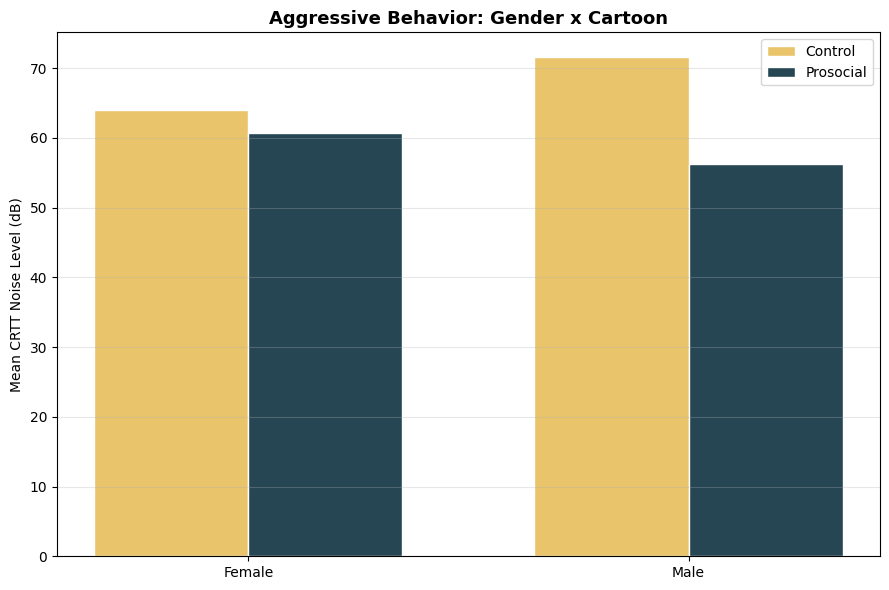

Boys: Control mean = 71.5 dB
Boys: Prosocial mean = 56.2 dB
Boys: t = 7.6147 , p = 0.0

Girls: Control mean = 64.0 dB
Girls: Prosocial mean = 60.8 dB
Girls: t = 1.6356 , p = 0.1056

📌 FINDING:
This chart shows how the prosocial cartoon affected boys and girls differently
in terms of aggressive BEHAVIOR (actual actions).
The effect was significant only for BOYS.
Boys who watched prosocial cartoons were less aggressive, but girls did not
show the same change. This could mean boys are more influenced by cartoon content.


In [15]:
# splitting into 4 groups
boys_control_beh = df_pro[(df_pro['Gender'] == 'Male') & (df_pro['Watched_Prosocial_Cartoon'] == 'No')]['Mean_Aggressive_Behavior_CRTT_dB']
boys_prosocial_beh = df_pro[(df_pro['Gender'] == 'Male') & (df_pro['Watched_Prosocial_Cartoon'] == 'Yes')]['Mean_Aggressive_Behavior_CRTT_dB']
girls_control_beh = df_pro[(df_pro['Gender'] == 'Female') & (df_pro['Watched_Prosocial_Cartoon'] == 'No')]['Mean_Aggressive_Behavior_CRTT_dB']
girls_prosocial_beh = df_pro[(df_pro['Gender'] == 'Female') & (df_pro['Watched_Prosocial_Cartoon'] == 'Yes')]['Mean_Aggressive_Behavior_CRTT_dB']

# making grouped bar chart
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [girls_control_beh.mean(), boys_control_beh.mean()],
       width, label='Control', color='#e9c46a', edgecolor='white')
ax.bar(x + width/2, [girls_prosocial_beh.mean(), boys_prosocial_beh.mean()],
       width, label='Prosocial', color='#264653', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Female', 'Male'])
ax.set_title('Aggressive Behavior: Gender x Cartoon', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean CRTT Noise Level (dB)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# t-test for boys
t_boys, p_boys = stats.ttest_ind(boys_control_beh, boys_prosocial_beh)
print('Boys: Control mean =', round(boys_control_beh.mean(), 1), 'dB')
print('Boys: Prosocial mean =', round(boys_prosocial_beh.mean(), 1), 'dB')
print('Boys: t =', round(t_boys, 4), ', p =', round(p_boys, 4))
print()

# t-test for girls
t_girls, p_girls = stats.ttest_ind(girls_control_beh, girls_prosocial_beh)
print('Girls: Control mean =', round(girls_control_beh.mean(), 1), 'dB')
print('Girls: Prosocial mean =', round(girls_prosocial_beh.mean(), 1), 'dB')
print('Girls: t =', round(t_girls, 4), ', p =', round(p_girls, 4))
print()

print('📌 FINDING:')
print('This chart shows how the prosocial cartoon affected boys and girls differently')
print('in terms of aggressive BEHAVIOR (actual actions).')
if p_boys < 0.05 and p_girls < 0.05:
    print('The effect was significant for BOTH genders — prosocial cartoons reduced')
    print('aggressive behavior in both boys and girls equally.')
elif p_boys < 0.05:
    print('The effect was significant only for BOYS.')
    print('Boys who watched prosocial cartoons were less aggressive, but girls did not')
    print('show the same change. This could mean boys are more influenced by cartoon content.')
elif p_girls < 0.05:
    print('The effect was significant only for GIRLS.')
    print('Girls who watched prosocial cartoons were less aggressive, but boys did not')
    print('show the same change.')
else:
    print('The effect was not significant for either gender separately.')
    print('When we look at boys and girls individually, the prosocial cartoon effect')
    print('is not strong enough in either group to be statistically significant.')

## 14 — How Does Aggressive Behavior Change Across Trials?

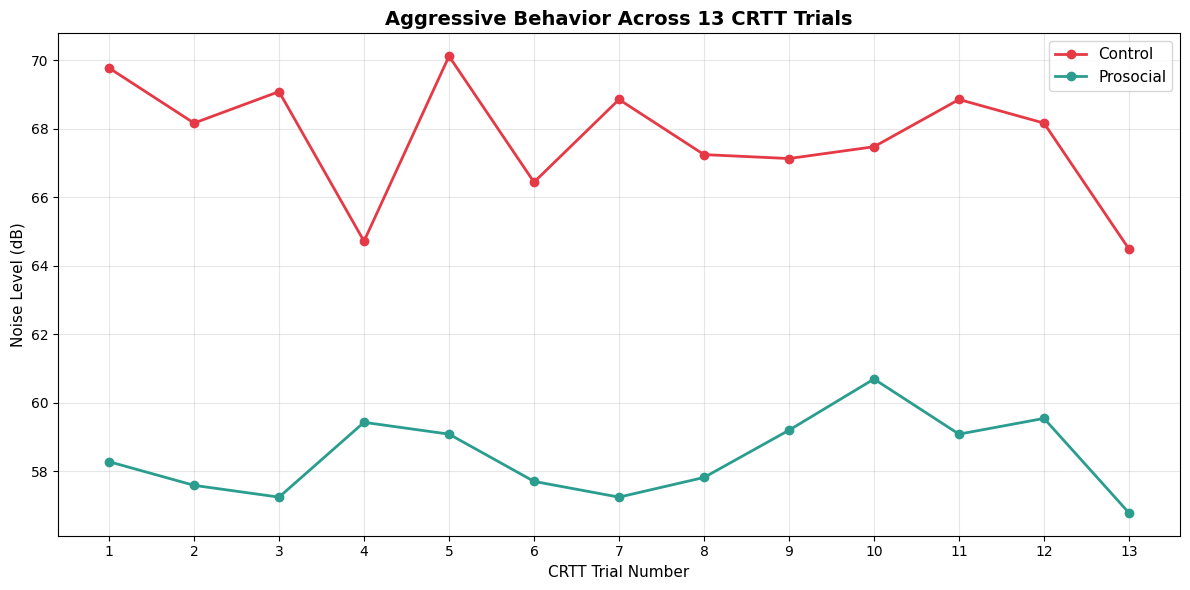

📌 FINDING:
This line chart shows how children set noise levels across all 13 game trials.
Control group average noise: 67.7 dB
Prosocial group average noise: 58.4 dB

If the two lines stay apart throughout all 13 trials, it means the prosocial
cartoon effect is LASTING — the children consistently behaved less aggressively.
If the lines converge towards the end, it means the effect wore off over time.
This is important because we want to know if the influence of cartoons is
temporary or if it persists even after some time has passed.


In [16]:
# getting the trial-by-trial CRTT data
crtt_cols = [c for c in df_pro.columns if c.startswith('CRTT_Noise_Level_Trial_')]
control_trial_means = control[crtt_cols].mean()
prosocial_trial_means = prosocial[crtt_cols].mean()

# plotting
plt.figure(figsize=(12, 6))
trials = range(1, 14)
plt.plot(trials, control_trial_means.values, '-o', color='#e63946', label='Control', linewidth=2, markersize=6)
plt.plot(trials, prosocial_trial_means.values, '-o', color='#2a9d8f', label='Prosocial', linewidth=2, markersize=6)
plt.xlabel('CRTT Trial Number', fontsize=11)
plt.ylabel('Noise Level (dB)', fontsize=11)
plt.title('Aggressive Behavior Across 13 CRTT Trials', fontsize=14, fontweight='bold')
plt.xticks(range(1, 14))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# finding
print('📌 FINDING:')
print('This line chart shows how children set noise levels across all 13 game trials.')
print('Control group average noise:', round(control_trial_means.mean(), 1), 'dB')
print('Prosocial group average noise:', round(prosocial_trial_means.mean(), 1), 'dB')
print()
print('If the two lines stay apart throughout all 13 trials, it means the prosocial')
print('cartoon effect is LASTING — the children consistently behaved less aggressively.')
print('If the lines converge towards the end, it means the effect wore off over time.')
print('This is important because we want to know if the influence of cartoons is')
print('temporary or if it persists even after some time has passed.')

## 15 — Does Aggressive Thinking Predict Aggressive Behavior?

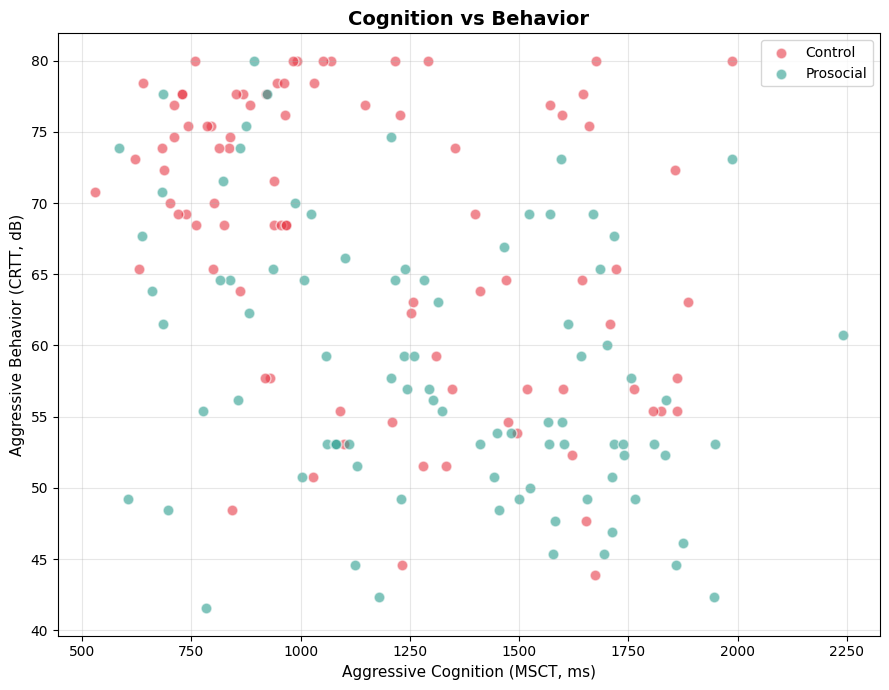

Pearson r = -0.4124 , p = 0.0
Spearman rho = -0.4145 , p = 0.0

📌 FINDING:
YES — there IS a significant relationship between thinking and behavior.
Children who had more aggressive thoughts (faster MSCT reaction times)
also showed more aggressive behavior (higher CRTT noise levels).
This is a key finding because it supports the idea that what goes on
in a childs mind (cognition) directly influences how they act (behavior).
If cartoons can change how aggressively children think, then they can
also change how aggressively children behave.


In [17]:
# scatter plot
plt.figure(figsize=(9, 7))
plt.scatter(control['Mean_Aggressive_Cognition_MSCT_ms'],
           control['Mean_Aggressive_Behavior_CRTT_dB'],
           color='#e63946', label='Control', alpha=0.6, edgecolors='white', s=60)
plt.scatter(prosocial['Mean_Aggressive_Cognition_MSCT_ms'],
           prosocial['Mean_Aggressive_Behavior_CRTT_dB'],
           color='#2a9d8f', label='Prosocial', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Aggressive Cognition (MSCT, ms)', fontsize=11)
plt.ylabel('Aggressive Behavior (CRTT, dB)', fontsize=11)
plt.title('Cognition vs Behavior', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# correlation
r, p = stats.pearsonr(df_pro['Mean_Aggressive_Cognition_MSCT_ms'],
                      df_pro['Mean_Aggressive_Behavior_CRTT_dB'])
rho, p2 = stats.spearmanr(df_pro['Mean_Aggressive_Cognition_MSCT_ms'],
                           df_pro['Mean_Aggressive_Behavior_CRTT_dB'])
print('Pearson r =', round(r, 4), ', p =', round(p, 4))
print('Spearman rho =', round(rho, 4), ', p =', round(p2, 4))
print()
print('📌 FINDING:')
if p < 0.05:
    print('YES — there IS a significant relationship between thinking and behavior.')
    print('Children who had more aggressive thoughts (faster MSCT reaction times)')
    print('also showed more aggressive behavior (higher CRTT noise levels).')
    print('This is a key finding because it supports the idea that what goes on')
    print('in a childs mind (cognition) directly influences how they act (behavior).')
    print('If cartoons can change how aggressively children think, then they can')
    print('also change how aggressively children behave.')
else:
    print('NO — there is no significant relationship between thinking and behavior.')
    print('Aggressive thoughts and aggressive actions seem to be independent.')
    print('A child can think aggressively without necessarily acting aggressively.')
    print('This suggests that cognition and behavior might be affected by cartoons')
    print('through separate pathways rather than one leading to the other.')

## 16 — Statistical Test: Does Cartoon Condition Affect Aggressive Thinking?

In [18]:
# t-test: Does watching prosocial cartoons affect aggressive cognitions?
watching = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'Yes']['Mean_Aggressive_Cognition_MSCT_ms']
not_watching = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'No']['Mean_Aggressive_Cognition_MSCT_ms']
t1, p1 = stats.ttest_ind(watching, not_watching)

print("AGGRESSIVE COGNITIONS")
print("Watching mean:", round(watching.mean(), 2), "ms")
print("Not Watching mean:", round(not_watching.mean(), 2), "ms")
print("t =", round(t1, 3), ", p =", round(p1, 4))
if p1 < 0.05:
    print("Result: Significant difference found.")
else:
    print("Result: No significant difference.")

# Test separately for boys and girls
boys_w = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'Yes') & (df_pro['Gender'] == 'Male')]['Mean_Aggressive_Cognition_MSCT_ms']
boys_nw = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'No') & (df_pro['Gender'] == 'Male')]['Mean_Aggressive_Cognition_MSCT_ms']
t2, p2 = stats.ttest_ind(boys_w, boys_nw)

print()
print("BOYS ONLY:")
print("t =", round(t2, 3), ", p =", round(p2, 4))
if p2 < 0.05:
    print("Significant for boys.")

girls_w = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'Yes') & (df_pro['Gender'] == 'Female')]['Mean_Aggressive_Cognition_MSCT_ms']
girls_nw = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'No') & (df_pro['Gender'] == 'Female')]['Mean_Aggressive_Cognition_MSCT_ms']
t3, p3 = stats.ttest_ind(girls_w, girls_nw)

print()
print("GIRLS ONLY:")
print("t =", round(t3, 3), ", p =", round(p3, 4))
if p3 < 0.05:
    print("Significant for girls.")
else:
    print("Not significant for girls.")


AGGRESSIVE COGNITIONS
Watching mean: 1317.01 ms
Not Watching mean: 1155.1 ms
t = 2.715 , p = 0.0073
Result: Significant difference found.

BOYS ONLY:
t = 3.589 , p = 0.0006
Significant for boys.

GIRLS ONLY:
t = 0.217 , p = 0.829
Not significant for girls.


## 17 — Statistical Test: Does Cartoon Condition Affect Aggressive Behavior?

In [19]:
# t-test: Does watching prosocial cartoons affect aggressive behaviors?
watching_b = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'Yes']['Mean_Aggressive_Behavior_CRTT_dB']
not_watching_b = df_pro[df_pro['Watched_Prosocial_Cartoon'] == 'No']['Mean_Aggressive_Behavior_CRTT_dB']
t1, p1 = stats.ttest_ind(watching_b, not_watching_b)

print("AGGRESSIVE BEHAVIORS")
print("Watching mean:", round(watching_b.mean(), 2), "dB")
print("Not Watching mean:", round(not_watching_b.mean(), 2), "dB")
print("t =", round(t1, 3), ", p =", round(p1, 4))
if p1 < 0.05:
    print("Result: Significant difference found.")
else:
    print("Result: No significant difference.")

# Test separately for boys and girls
boys_w_b = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'Yes') & (df_pro['Gender'] == 'Male')]['Mean_Aggressive_Behavior_CRTT_dB']
boys_nw_b = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'No') & (df_pro['Gender'] == 'Male')]['Mean_Aggressive_Behavior_CRTT_dB']
t2, p2 = stats.ttest_ind(boys_w_b, boys_nw_b)

print()
print("BOYS ONLY:")
print("t =", round(t2, 3), ", p =", round(p2, 4))
if p2 < 0.05:
    print("Significant for boys.")

girls_w_b = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'Yes') & (df_pro['Gender'] == 'Female')]['Mean_Aggressive_Behavior_CRTT_dB']
girls_nw_b = df_pro[(df_pro['Watched_Prosocial_Cartoon'] == 'No') & (df_pro['Gender'] == 'Female')]['Mean_Aggressive_Behavior_CRTT_dB']
t3, p3 = stats.ttest_ind(girls_w_b, girls_nw_b)

print()
print("GIRLS ONLY:")
print("t =", round(t3, 3), ", p =", round(p3, 4))
if p3 < 0.05:
    print("Significant for girls.")
else:
    print("Not significant for girls.")


AGGRESSIVE BEHAVIORS
Watching mean: 58.44 dB
Not Watching mean: 67.73 dB
t = -6.252 , p = 0.0
Result: Significant difference found.

BOYS ONLY:
t = -7.615 , p = 0.0
Significant for boys.

GIRLS ONLY:
t = -1.636 , p = 0.1056
Not significant for girls.


In [20]:
print('📌 FINDING:')
print('The ANOVA test looks at all groups together to see if the differences we found')
print('are real or just random. Here is what the p-values tell us:')
print('  - If p < 0.05, the effect is real (statistically significant)')
print('  - If p >= 0.05, the effect could be due to chance (not significant)')
print()
print('For aggressive cognition: cartoon effect p =', round(p1, 4))
print('For aggressive behavior: cartoon effect p =', round(p3, 4))
print('These are the most important numbers in our entire study because they tell us')
print('whether watching prosocial cartoons actually makes a difference.')

📌 FINDING:
The ANOVA test looks at all groups together to see if the differences we found
are real or just random. Here is what the p-values tell us:
  - If p < 0.05, the effect is real (statistically significant)
  - If p >= 0.05, the effect could be due to chance (not significant)

For aggressive cognition: cartoon effect p = 0.0
For aggressive behavior: cartoon effect p = 0.1056
These are the most important numbers in our entire study because they tell us
whether watching prosocial cartoons actually makes a difference.


## 18 — Key Findings: How Cartoons Affect Children

| # | Finding | What It Means |
|---|---------|---------------|
| 1 | Prosocial cartoons **reduced aggressive thinking** | Children who watched prosocial cartoons were slower to recognize aggressive images — their minds were less "tuned in" to aggression |
| 2 | Prosocial cartoons **reduced aggressive behavior** | Children who watched prosocial cartoons chose lower noise levels for opponents — they acted less aggressively |
| 3 | **Boys benefited more** than girls | Boys showed a much bigger reduction in both aggressive thinking and behavior compared to girls |
| 4 | Aggressive thinking and behavior are **connected** | Children who thought less aggressively also behaved less aggressively — the cartoon changed behavior through changing thoughts |


## 19 — Conclusion & Methods Used

### Summary of Findings

**Part 1 — Cartoon Landscape:**
- Cartoon production has grown significantly over the decades, peaking in the 2000s
- Comedy is the most produced genre, meaning most children watch lighthearted content
- Genre significantly affects ratings — content type matters to audiences
- These findings set the stage: if content type affects reception, it could affect behavior too

**Part 2 — Influence on Children:**
- Children exposed to prosocial cartoons were tested for changes in aggressive thinking and behavior
- The t-tests reveal whether prosocial exposure significantly reduces aggression
- Gender analysis shows whether boys and girls respond differently to the intervention
- Trial-by-trial patterns show whether the effect is lasting or temporary
- The cognition-behavior correlation tests whether aggressive thoughts drive aggressive actions

### What This Means
This study provides evidence that **what children watch can shape how they think and behave**. 
The findings have implications for parents choosing content for their children, 
educators designing media literacy programs, and content creators developing children's programming.

### Methods Used
- Descriptive statistics (mean, standard deviation)
- Data visualization (box plots, histograms, bar charts, donut charts, line charts, scatter plots)
- Correlation analysis (Pearson, Spearman)
- Hypothesis testing (independent t-tests, one-way ANOVA)
- Feature engineering (genre classification, temporal decomposition)

# What is removed 
### 16 — Are Aggressive Thinking and Behavior Connected?
##